In [18]:
import pandas as pd
import numpy as np
from datetime import date
import os
from tqdm import tqdm # for progress bar
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import random 
from Bio import pairwise2
import csv
import sys
from sklearn.linear_model import LinearRegression as LR
import statsmodels.api as sm
import scipy.stats as ss
import pylab
import mplcursors
import math
from IPython.core.display import display, HTML
import io
import zipfile
from PIL import Image
import pickle
from data.sequencing import data_analysis
from data.sequencing import visualization
from data.sequencing import data_import
import matplotlib.patches as patches

# Import non-seq data

In [19]:
dists = data_import.import_dists()
dfs = pd.read_csv('dfs.csv')
dfs

,Unnamed: 0,feature_seq
0,0,ACCGGTAAGGCACAAAAACG
1,1,ATTTGCAAGGAACAAAAACG
2,2,ACCTGTAAGGCACAAAAACG
3,3,AATTGCAAGGAACAAAAACG
4,4,ACCGGTAAGGTACAAAAACG
...,...,...
452,452,TCCGGTAAGGCACAGAAACG
453,453,ACGGGTAAGGAACAAAAACG
454,454,GGCGGTAAGGCACAAAAACG
455,455,ACTTGCAAGGCACAGAAACG


In [34]:
queries = {'cat' : 'ACCGGTAAGGCACAGAAACG',
           'dna' : 'ATGTGTAAGGCACAAAAACG',
           'frame' : 'ATACGCAAGGAACAAAAACG',
           'building' : 'ATTTGCAAGGAACAAAAACG',
          'lego' : 'ACCTGTAAGGCACAGAAACG'}

bls = ['bl1', 'bl2', 'bl3', 'avg']

# Load data
q_path = '/tf/primo/data/experiments/retrieved/enrichments'
bl_path = '/tf/primo/data/experiments/baseline/enrichments'
bl_enrichments = {}
exp_enrichments = {}

for k in queries.keys():
    exp_enrichments[k] = pd.read_csv(f'{q_path}/{k}_new.csv')
    
for k in bls:
    bl_enrichments[k] = pd.read_csv(f'{bl_path}/{k}_new.csv')

In [21]:
# Filter out low read count sequences
seqs_to_rmv = [456, 119, 227]

bl_enrichments_rmv = {}
exp_enrichments_rmv = {}

for k,v in bl_enrichments.items():
    bl_enrichments_rmv[k] = v.loc[~v['seq_id'].isin(seqs_to_rmv)]
    
for k,v in exp_enrichments.items():
    exp_enrichments_rmv[k] = v.loc[~v['seq_id'].isin(seqs_to_rmv)]

# Compare enrichment to predicted activity

0.6846332153712821
0.6651208191990011
0.6239728595187642
0.742534788525861
0.7891251628170493


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:

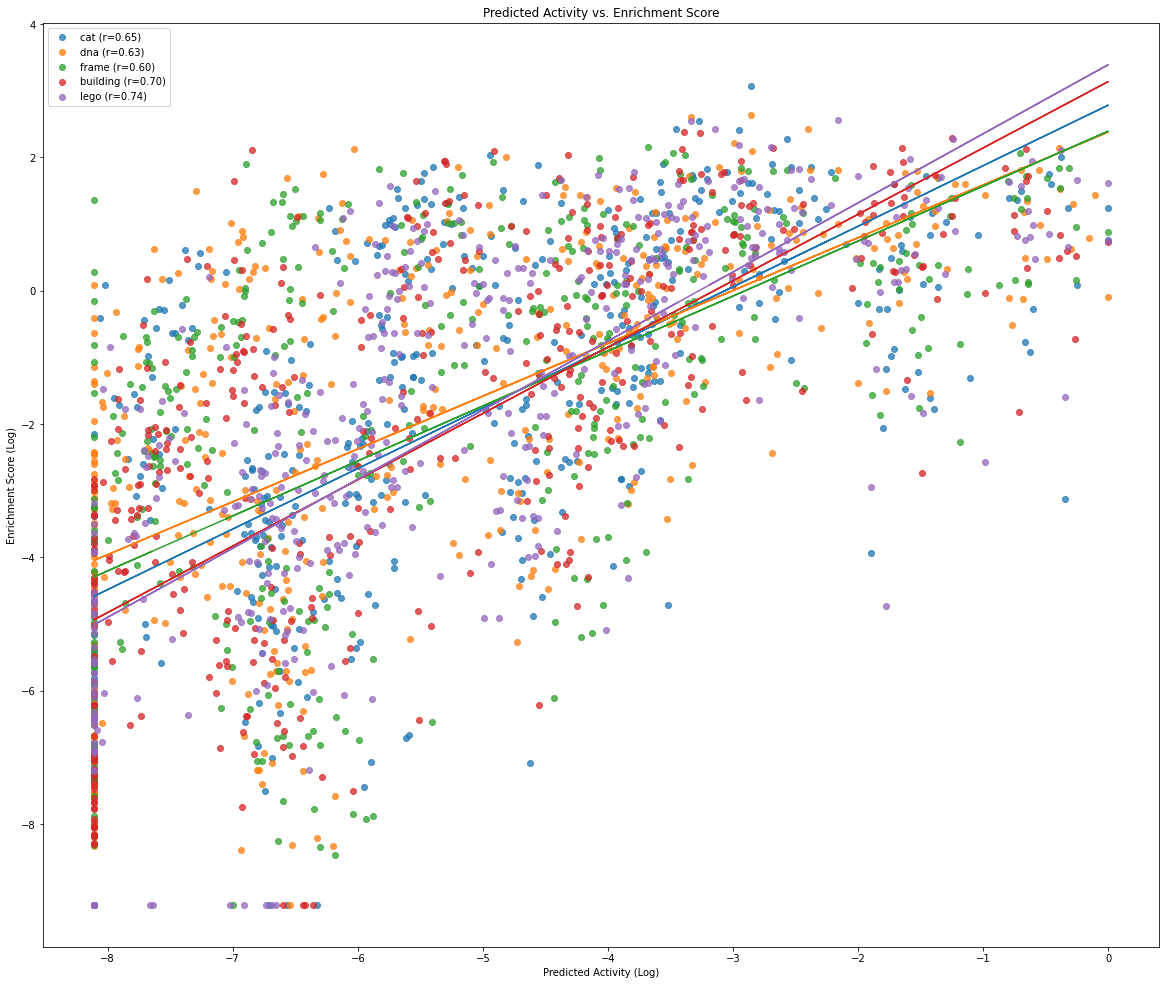

In [22]:
plt.figure()

for k, v in exp_enrichments_rmv.items():
    v['relative_enrichment_log'] = np.log(v['relative_enrichment'] + 1e-4)
    v['pred_activity_log'] = np.log(v['pred_activity'] + 1e-4)

    pearson_corr = v[['pred_activity_log', 'relative_enrichment_log']].corr(method='pearson').iloc[0, 1]
    spearman_corr = v[['pred_activity_log', 'relative_enrichment_log']].corr(method='spearman').iloc[0, 1]
    slope, intercept, r_value, p_value, std_err = ss.linregress(v['pred_activity_log'], v['relative_enrichment_log'])

    # Plotting
    plt.scatter(v['pred_activity_log'], v['relative_enrichment_log'], label=f'{k} (r={pearson_corr:.2f})', alpha=0.75)
    plt.plot(v['pred_activity_log'], intercept + slope * v['pred_activity_log'])
    print(spearman_corr)

plt.xlabel('Predicted Activity (Log)')
plt.ylabel('Enrichment Score (Log)')
plt.title('Predicted Activity vs. Enrichment Score')
plt.legend()


# Plot heatmap

In [23]:
df = pd.DataFrame()
num_2_seq = pd.read_csv('dfs.csv')
n2sf = num_2_seq[~num_2_seq['Unnamed: 0'].isin(seqs_to_rmv)]

df['bl1_reads'] = bl_enrichments['bl1']['reads']
df['bl2_reads'] = bl_enrichments['bl2']['reads']
for k,v in exp_enrichments_rmv.items():
    df[k+'_pred_activity'] = v['pred_activity']
    df[k+'_enr_score'] = v['relative_enrichment'].fillna(0)
    df[k+'_reads'] = v['reads']


dfm = n2sf.merge(df, left_index=True, right_index=True)

In [24]:
yd = pd.read_csv('/tf/primo/data/simulation/targets/yields_dists_new.csv').set_index("Photo_ID")
y1 = pd.read_hdf('/tf/primo/data/targets/query_target_dists_new.h5').rename(columns = {'index': 'Photo_ID'})
yd['lego'] = y1['luis_lego']
label_lkup = {'callie_janelle' :'cat',
              'webb_deep' :'webb',
              'dna_1' :'dna',
              'frame_352' :'bigfoot',
             'yuan_taipei': 'building',
              
             'FeatureSequence': 'feature_seq'}
yd = yd.rename(columns=label_lkup)
yd['Photo_ID'] = yd.index
ydk = yd[['Photo_ID','feature_seq', 'cat', 'webb', 'dna', 'building', 'bigfoot', 'lego' ]]

In [25]:
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none',
}
merged_df = merged_df.rename(columns={'bigfoot': 'frame'})

In [26]:
cdf = pd.DataFrame()
cdf['feature_seq'] = dfm['feature_seq']
for k,v in exp_enrichments_rmv.items():
    cdf[k+'_enr_score'] = dfm[k+'_enr_score']
    cdf[k+'_reads'] = dfm[k+'_reads']
    cdf[k+'_pred_activity'] = dfm[k+'_pred_activity']

merged_df = pd.merge(cdf, ydk, on='feature_seq', how='left')

In [29]:
merged_df = merged_df.rename(columns={'bigfoot': 'frame'})

In [30]:
for k in queries.keys():
    merged_df[k+'_pos_or_neg'] = np.where(merged_df[k] > 75, 0, 1)
    merged_df[k+'_sim_pos_or_neg'] = np.where(merged_df[k+'_pred_activity'] < .2, 0, 1)
    merged_df[k+'_exp_pos_or_neg'] = np.where(merged_df[k+'_enr_score'] <= 1, 0, 1)
    
    
    

In [31]:
def manual_f1_score(y_true, y_pred):
    true_positive = sum(1 for true, pred in zip(y_true, y_pred) if true == pred == 1)
    false_positive = sum(1 for true, pred in zip(y_true, y_pred) if true == 0 and pred == 1)
    false_negative = sum(1 for true, pred in zip(y_true, y_pred) if true == 1 and pred == 0)
    true_negative = sum(1 for true, pred in zip(y_true, y_pred) if true == pred == 0)
    
    precision = true_positive / (true_positive + false_positive) if true_positive + false_positive else 0
    recall = true_positive / (true_positive + false_negative) if true_positive + false_negative else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0
    totalpos = sum(1 for true in y_true if true == 1)
    totalneg = sum(1 for true in y_true if true == 0)
    return [true_positive/totalpos, false_negative/totalpos, true_negative/totalneg, false_positive/totalneg]
    #return f1



In [35]:
for k in queries.keys():
    score_manual_exp = manual_f1_score(merged_df[k+'_pos_or_neg'], merged_df[k+'_exp_pos_or_neg'])
    
    print(k+':')
    print('%.6f' % score_manual_exp[0])
    print('%.6f' % score_manual_exp[1])
    print('%.6f' % score_manual_exp[2])
    print('%.6f' % score_manual_exp[3])
    print()
    print()

cat:
0.979167
0.020833
0.676442
0.323558


dna:
0.737887
0.262113
0.599956
0.400044


frame:
0.618336
0.381664
0.641431
0.358569


building:
0.696380
0.303620
0.747645
0.252355


lego:
0.486299
0.513701
0.837840
0.162160




In [36]:
for k in queries.keys():
    score_manual_exp = manual_f1_score(merged_df[k+'_pos_or_neg'], merged_df[k+'_exp_pos_or_neg'])
    
    print(k+':')
    print('%.6f' % score_manual_exp[0])
    print('%.6f' % score_manual_exp[1])
    print('%.6f' % score_manual_exp[2])
    print('%.6f' % score_manual_exp[3])
    print()
    print()

cat:
0.979167
0.020833
0.676442
0.323558


dna:
0.737887
0.262113
0.599956
0.400044


frame:
0.618336
0.381664
0.641431
0.358569


building:
0.696380
0.303620
0.747645
0.252355


lego:
0.486299
0.513701
0.837840
0.162160




In [38]:
merged_df

,feature_seq,cat_enr_score,cat_reads,cat_pred_activity,dna_enr_score,dna_reads,dna_pred_activity,frame_enr_score,frame_reads,frame_pred_activity,...,dna_exp_pos_or_neg,frame_pos_or_neg,frame_sim_pos_or_neg,frame_exp_pos_or_neg,building_pos_or_neg,building_sim_pos_or_neg,building_exp_pos_or_neg,lego_pos_or_neg,lego_sim_pos_or_neg,lego_exp_pos_or_neg
0,ACCGGTAAGGCACAAAAACG,5.947467,6684.0,0.108923,2.929151,11662.0,0.146470,0.006602,20.0,0.000764,...,1,0,0,0,0,0,0,0,0,1
1,ACCGGTAAGGCACAAAAACG,5.947467,6684.0,0.108923,2.929151,11662.0,0.146470,0.006602,20.0,0.000764,...,1,0,0,0,0,0,0,0,0,1
2,ACCGGTAAGGCACAAAAACG,5.947467,6684.0,0.108923,2.929151,11662.0,0.146470,0.006602,20.0,0.000764,...,1,0,0,0,0,0,0,0,0,1
3,ACCGGTAAGGCACAAAAACG,5.947467,6684.0,0.108923,2.929151,11662.0,0.146470,0.006602,20.0,0.000764,...,1,0,0,0,0,0,0,0,0,1
4,ACCGGTAAGGCACAAAAACG,5.947467,6684.0,0.108923,2.929151,11662.0,0.146470,0.006602,20.0,0.000764,...,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1741974,TCCGGTAAGGCACAGAAACG,2.133828,3208.0,1.000000,0.820126,4368.0,0.006623,0.000000,0.0,0.000200,...,0,0,0,0,0,0,0,0,1,1
1741975,ACGGGTAAGGAACAAAAACG,0.168506,411.0,0.009114,0.555041,4796.0,0.022702,0.002129,14.0,0.011770,...,0,1,0,0,0,0,0,0,0,0
1741976,ACGGGTAAGGAACAAAAACG,0.168506,411.0,0.009114,0.555041,4796.0,0.022702,0.002129,14.0,0.011770,...,0,1,0,0,0,0,0,0,0,0
1741977,GGCGGTAAGGCACAAAAACG,2.010502,1298.0,0.123058,0.216425,495.0,0.241379,0.001149,2.0,0.001259,...,0,0,0,0,0,0,0,0,0,1


In [39]:
merged_df.value_counts('feature_seq').index

Index(['AGGGGTAAGGTACAAAAACG', 'ATTTGCAAGGAACAAAAACG', 'ATTCGCAAGGAACAAAAACG',
       'ACCGGTAAGGTACAAAAACG', 'ACCTGTAAGGCACAAAAACG', 'ATACGCAAGGCACAGAAACG',
       'ACCCGTAAGGCACAGAAACG', 'AGGGGCAAGGTACAAAAACG', 'AATTGCAAGGAACAAAAACG',
       'ACGGGTAAGGTACAAAAACG',
       ...
       'ATATGCAAGGTACAAAAACG', 'ATATGTAAGGTACAAAAACG', 'ATCCGTAAGGAACAGAAACG',
       'ATCCGTAAGGTACAGAAACG', 'ATCGGCAAGGAACAGAAACG', 'AAGCGTAAGGCACAAAAACG',
       'ATCTGCAAGGTACAAAAACG', 'ATCTGTAAGGAACAGAAACG', 'ATGCGTAAGGAACAGAAACG',
       'TCCTGTAAGGCACAGAAACG'],
      dtype='object', name='feature_seq', length=454)

In [40]:
df = pd.DataFrame()
df['feature_seq'] = merged_df.value_counts('feature_seq').index
df['count'] = merged_df.value_counts('feature_seq').values

for k in queries.keys():
    tmp_sim = []
    tmp_diff = []
    min_l = []
    max_l = []
    es_l = []
    pa_l = []
    print(k)
    for i in merged_df.value_counts('feature_seq').index:
        tmp = merged_df[merged_df['feature_seq'] == i]
        num_sim = len(tmp[tmp[k] <= 75])
        num_diff = len(tmp[tmp[k] > 75])
        min_ = tmp[k].min()
        max_ = tmp[k].max()
        es = tmp[k+'_enr_score'].min()
        pa = tmp[k+'_pred_activity'].max()
        
        es_l.append(es)
        pa_l.append(pa)
        min_l.append(min_)
        max_l.append(max_)
        tmp_sim.append(num_sim)
        tmp_diff.append(num_diff)
    
    df[k+'_pa'] = pa_l
    df[k+'_es'] = es_l
    df[k+'_min'] = min_l
    df[k+'_max'] = max_l
    df[k+'_sim'] = tmp_sim
    df[k+'_diff'] = tmp_diff
    
        

cat
dna
frame
building
lego


In [41]:
dfm

,Unnamed: 0,feature_seq,bl1_reads,bl2_reads,cat_pred_activity,cat_enr_score,cat_reads,dna_pred_activity,dna_enr_score,dna_reads,frame_pred_activity,frame_enr_score,frame_reads,building_pred_activity,building_enr_score,building_reads,lego_pred_activity,lego_enr_score,lego_reads
0,0,ACCGGTAAGGCACAAAAACG,1328.0,161.0,0.108923,5.947467,6684.0,0.146470,2.929151,11662.0,0.000764,0.006602,20.0,0.000766,0.003782,11.0,0.031931,4.953384,3256.0
1,1,ATTTGCAAGGAACAAAAACG,4415.0,692.0,0.000200,0.000943,4.0,0.004514,0.228272,3430.0,0.324764,1.375007,15721.0,1.000000,2.071799,22741.0,0.000364,0.083844,208.0
2,2,ACCTGTAAGGCACAAAAACG,1829.0,345.0,0.038301,4.513935,8780.0,0.499635,6.159567,42444.0,0.001044,0.009918,52.0,0.002614,0.087212,439.0,0.108923,3.589785,4084.0
3,3,AATTGCAAGGAACAAAAACG,1763.0,322.0,0.000200,0.000543,1.0,0.003070,0.194123,1266.0,0.220916,1.459584,7243.0,0.680235,2.314000,11024.0,0.000354,0.030648,33.0
4,4,ACCGGTAAGGTACAAAAACG,2232.0,305.0,0.014696,0.516066,1032.0,0.019763,0.109678,777.0,0.001258,0.000371,2.0,0.001262,0.000966,5.0,0.004308,0.835299,977.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
451,451,ATGTGCAAGGTACAAAAACG,1343.0,182.0,0.000200,0.000834,1.0,0.007015,2.331497,9898.0,0.036464,0.861524,2783.0,0.081084,2.532229,7853.0,0.000392,0.044228,31.0
452,452,TCCGGTAAGGCACAGAAACG,1857.0,204.0,1.000000,2.133828,3208.0,0.006623,0.820126,4368.0,0.000200,0.000000,0.0,0.000200,0.000000,0.0,0.526144,3.284310,2888.0
453,453,ACGGGTAAGGAACAAAAACG,2213.0,444.0,0.009114,0.168506,411.0,0.022702,0.555041,4796.0,0.011770,0.002129,14.0,0.010486,0.001901,12.0,0.002672,0.002103,3.0
454,454,GGCGGTAAGGCACAAAAACG,639.0,110.0,0.123058,2.010502,1298.0,0.241379,0.216425,495.0,0.001259,0.001149,2.0,0.001263,0.000000,0.0,0.036075,1.591572,601.0


In [42]:
newdf = pd.merge(dfm, df, on = 'feature_seq')

In [43]:
newdf

,Unnamed: 0,feature_seq,bl1_reads,bl2_reads,cat_pred_activity,cat_enr_score,cat_reads,dna_pred_activity,dna_enr_score,dna_reads,...,building_min,building_max,building_sim,building_diff,lego_pa,lego_es,lego_min,lego_max,lego_sim,lego_diff
0,0,ACCGGTAAGGCACAAAAACG,1328.0,161.0,0.108923,5.947467,6684.0,0.146470,2.929151,11662.0,...,71.341790,164.491700,24,20937,0.031931,4.953384,66.456528,161.908890,307,20654
1,1,ATTTGCAAGGAACAAAAACG,4415.0,692.0,0.000200,0.000943,4.0,0.004514,0.228272,3430.0,...,43.344060,169.876160,47128,95507,0.000364,0.083844,68.560982,171.432312,298,142337
2,2,ACCTGTAAGGCACAAAAACG,1829.0,345.0,0.038301,4.513935,8780.0,0.499635,6.159567,42444.0,...,64.425730,193.207470,408,84512,0.108923,3.589785,61.532028,190.473419,1724,83196
3,3,AATTGCAAGGAACAAAAACG,1763.0,322.0,0.000200,0.000543,1.0,0.003070,0.194123,1266.0,...,45.326668,155.055980,21595,31963,0.000354,0.030648,68.121559,164.153366,306,53252
4,4,ACCGGTAAGGTACAAAAACG,2232.0,305.0,0.014696,0.516066,1032.0,0.019763,0.109678,777.0,...,68.567670,187.596620,424,125179,0.004308,0.835299,67.071587,191.434280,1443,124160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,451,ATGTGCAAGGTACAAAAACG,1343.0,182.0,0.000200,0.000834,1.0,0.007015,2.331497,9898.0,...,92.735530,96.578835,0,3,0.000392,0.044228,101.622307,109.145012,0,3
450,452,TCCGGTAAGGCACAGAAACG,1857.0,204.0,1.000000,2.133828,3208.0,0.006623,0.820126,4368.0,...,89.258870,89.258870,0,1,0.526144,3.284310,91.403389,91.403389,0,1
451,453,ACGGGTAAGGAACAAAAACG,2213.0,444.0,0.009114,0.168506,411.0,0.022702,0.555041,4796.0,...,76.578060,81.618530,0,2,0.002672,0.002103,79.000359,83.294006,0,2
452,454,GGCGGTAAGGCACAAAAACG,639.0,110.0,0.123058,2.010502,1298.0,0.241379,0.216425,495.0,...,91.927284,91.927284,0,1,0.036075,1.591572,90.893524,90.893524,0,1


In [ ]:
newdf.to_csv('bin_summary_2.csv')

In [ ]:
df_sample

In [ ]:
merged_df

In [ ]:
for k in queries.keys():
    recall_data = []
    false_positive_data = []
    thresholds = merged_df[k+'_pred_activity'].unique()
    thresholds.sort()
    pairs_s = merged_df[merged_df[k] <= 75]
    pairs_d = merged_df[merged_df[k] > 75]

    for t in thresholds:
        recall = len(pairs_s[pairs_s[k+'_pred_activity'] > t])/len(pairs_s)
        false_positive = len(pairs_d[pairs_d[k+'_pred_activity'] > t])/len(pairs_d)
        recall_data.append(recall)
        false_positive_data.append(false_positive)
    plt.figure(figsize=(10, 5))   
    plt.scatter(false_positive_data, recall_data, c=thresholds, cmap=plt.cm.viridis_r)
    plt.plot(false_positive_data, false_positive_data, linestyle='dashed', color='grey')
    plt.ylabel("Proportion Correctly Retrieved")
    plt.xlabel("Proportion Mistakenly Retrieved")
    plt.colorbar(label="Yield Threshold")
    plt.title("20nt Cas9 Model - "+k)

In [ ]:
merged_df

1741979
13481
1741979
13577
1741979
15221
1741979
13991
1741979
14566


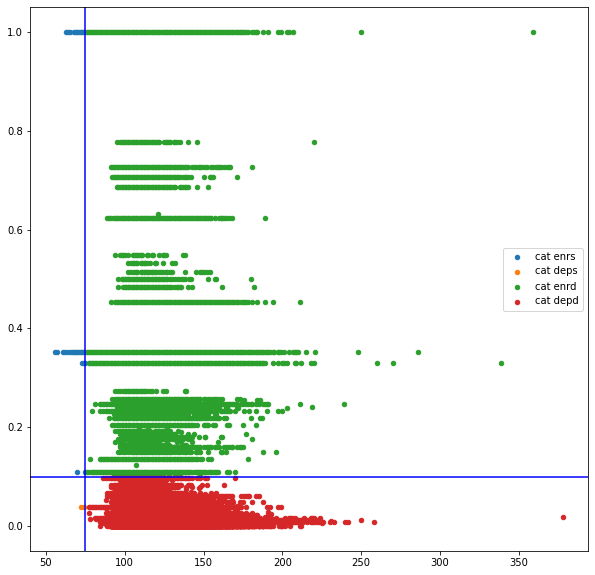

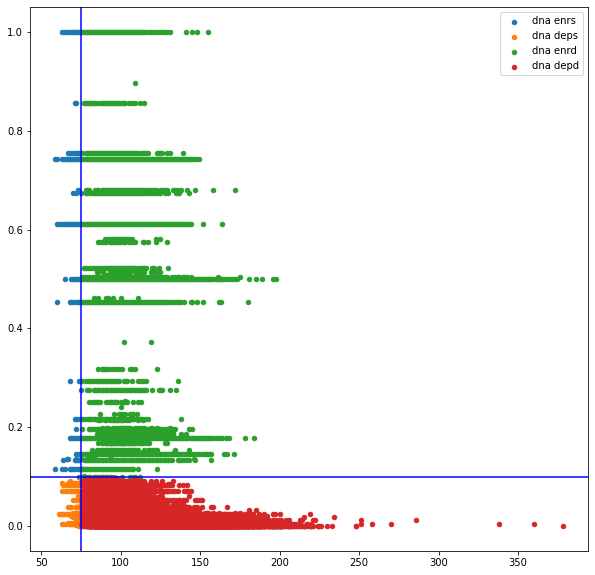

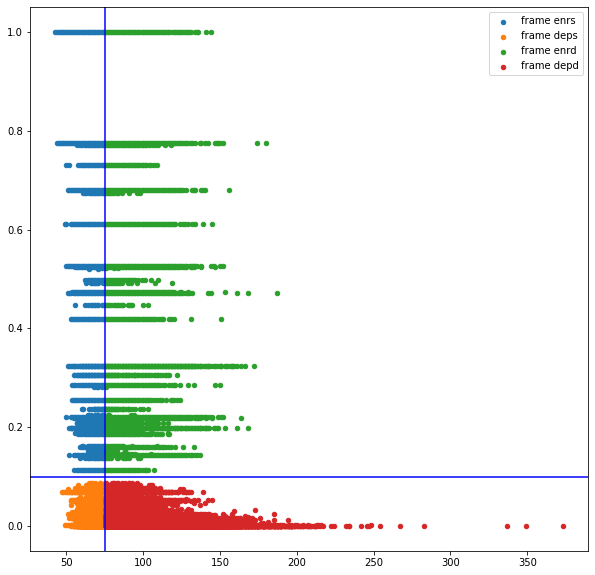

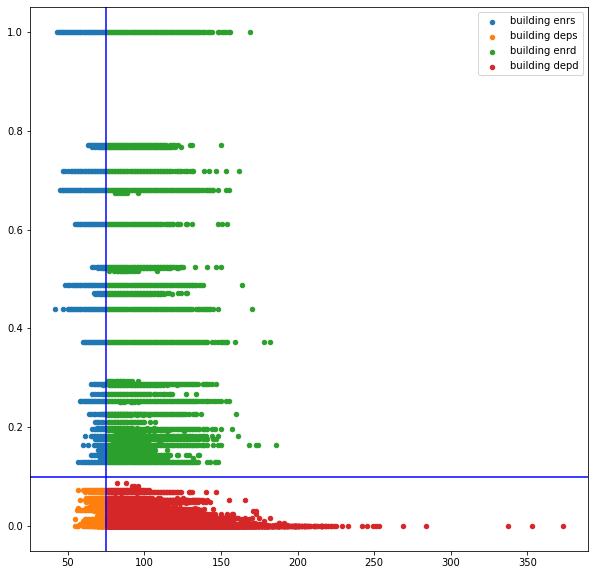

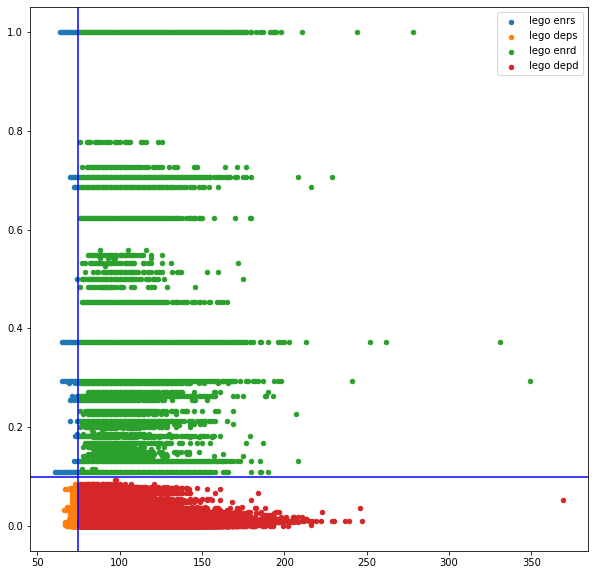

In [44]:
for k in queries.keys():
    merged_df[k] = merged_df[k].astype(int)
    print(len(merged_df))
    newdf = merged_df.drop_duplicates(subset=[k, k+'_pred_activity'])
    print(len(newdf))
    enrs = newdf[(newdf[k+'_pred_activity'] > .1) & (newdf[k] <= 75)].sort_values(by=k)
    deps = newdf[(newdf[k+'_pred_activity'] <= .1) & (newdf[k] <= 75)].sort_values(by=k)
    enrd = newdf[(newdf[k+'_pred_activity'] > .1) & (newdf[k] > 75)].sort_values(by=k)
    depd = newdf[(newdf[k+'_pred_activity'] <= .1) & (newdf[k] > 75)].sort_values(by=k)

    plt.figure(figsize=(10, 10)) 
    plt.scatter(enrs[k], enrs[k+'_pred_activity'], label=k+' enrs', s=20)
    plt.scatter(deps[k], deps[k+'_pred_activity'], label=k+' deps', s=20)
    plt.scatter(enrd[k], enrd[k+'_pred_activity'], label=k+' enrd', s=20)
    plt.scatter(depd[k], depd[k+'_pred_activity'], label=k+' depd', s=20)

    plt.axvline(x=75, color='b', linestyle='-')
    plt.axhline(y=.1, color='b', linestyle='-')
    plt.legend()
    plt.rcParams.update(new_rc_params)
    #plt.savefig(k+".svg", transparent=True, dpi=600, bbox_inches='tight', format='svg')
    # Clear the set for the next iteration
    

In [45]:
merged_df['cat_pred_activity'].value_counts()

0.000200    536594
0.006658    265458
0.014696    125603
0.038301     84920
0.009406     84044
             ...  
0.019489         1
0.004220         1
0.031426         1
0.002490         1
0.026788         1
Name: cat_pred_activity, Length: 402, dtype: int64

In [46]:
value_counts.index

NameError: name 'value_counts' is not defined

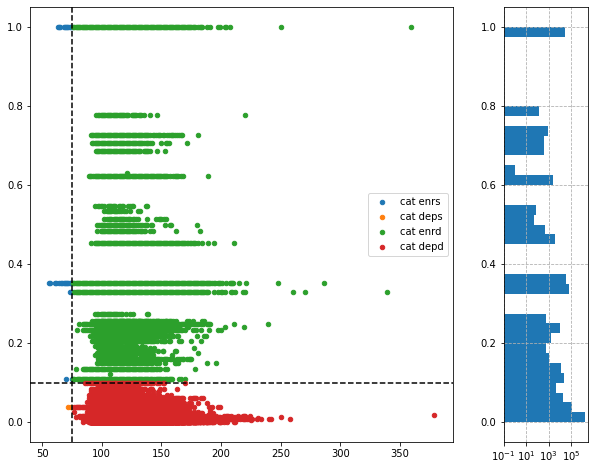

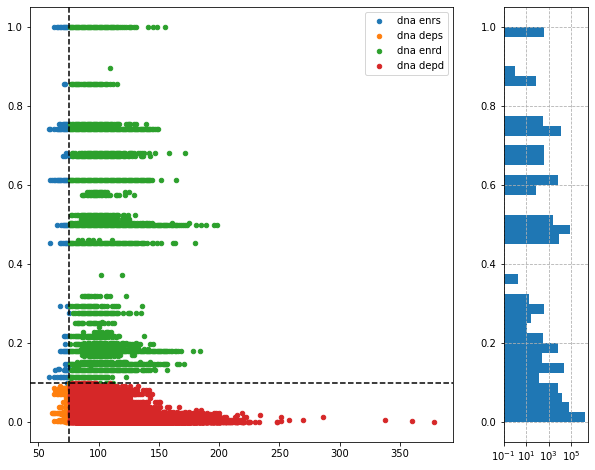

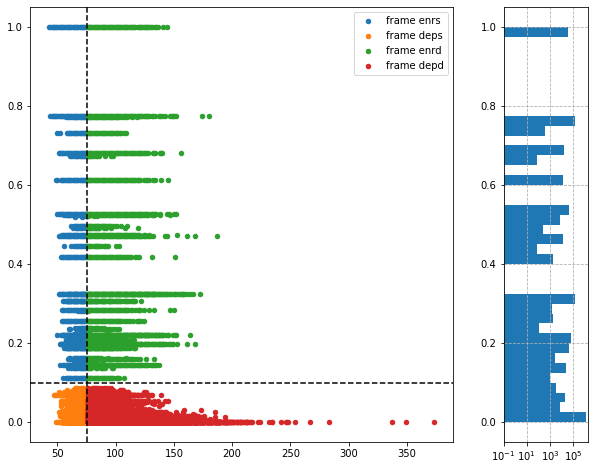

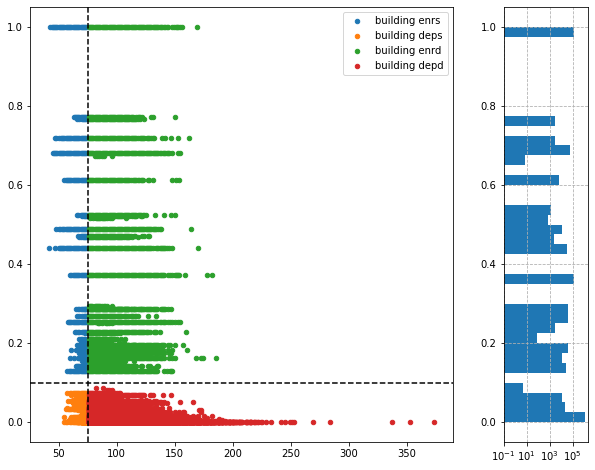

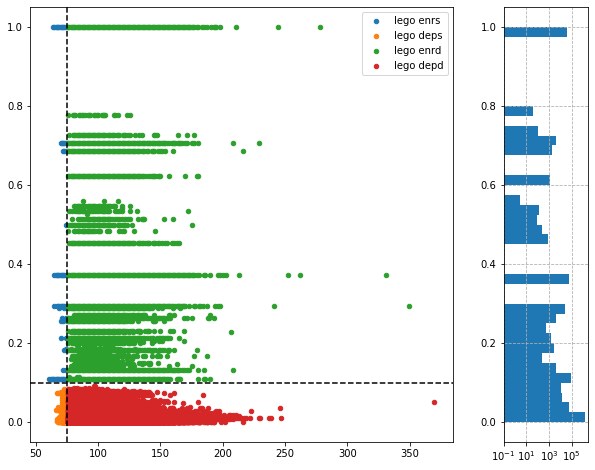

In [47]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

for k in queries.keys():
    merged_df[k] = merged_df[k].astype(int)
    newdf = merged_df.drop_duplicates(subset=[k, k+'_pred_activity'])
    enrs = newdf[(newdf[k+'_pred_activity'] > .1) & (newdf[k] <= 75)].sort_values(by=k)
    deps = newdf[(newdf[k+'_pred_activity'] <= .1) & (newdf[k] <= 75)].sort_values(by=k)
    enrd = newdf[(newdf[k+'_pred_activity'] > .1) & (newdf[k] > 75)].sort_values(by=k)
    depd = newdf[(newdf[k+'_pred_activity'] <= .1) & (newdf[k] > 75)].sort_values(by=k)

    fig, (ax_scatter, ax_hist) = plt.subplots(1, 2, gridspec_kw={"width_ratios": [5, 1]}, figsize=(10, 8))

    ax_scatter.scatter(enrs[k], enrs[k+'_pred_activity'], label=k+' enrs', s=20)
    ax_scatter.scatter(deps[k], deps[k+'_pred_activity'], label=k+' deps', s=20)
    ax_scatter.scatter(enrd[k], enrd[k+'_pred_activity'], label=k+' enrd', s=20)
    ax_scatter.scatter(depd[k], depd[k+'_pred_activity'], label=k+' depd', s=20)
    ax_scatter.axvline(x=75, color='black', linestyle='--')
    ax_scatter.axhline(y=.1, color='black', linestyle='--')
    ax_scatter.legend()

    min_x_limit = 0.1

    ax_hist.hist(merged_df[k+'_pred_activity'], bins=40, orientation='horizontal')
    ax_hist.set_xscale('log')
    ax_hist.set_ylim(ax_scatter.get_ylim())
    ax_hist.set_xlim(left=min_x_limit)  # Set the lower limit for the x-axis
    ax_hist.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=5))
    ax_hist.grid(which='major', linestyle='--')

    ##plt.savefig(k+".svg", transparent=True, dpi=600, bbox_inches='tight', format='svg')
    plt.show()


In [ ]:
for k in queries.keys():
    num_enr = len(merged_df[merged_df[k+'_enr_score'] >1])
    num_sim = len(merged_df[merged_df[k] <75])
    print(k)
    print(num_enr)
    print(num_sim)

In [ ]:
df_sample

In [ ]:
for k in queries.keys():
    print(len(df_sample[(df_sample[k+'_pred_activity_norm'] > .1) & (df_sample[k] <= 75)]))
    print(len(df_sample[(df_sample[k+'_pred_activity_norm'] <= .1) & (df_sample[k] <= 75)]))
    print(len(df_sample[(df_sample[k+'_pred_activity_norm'] > .1) & (df_sample[k] > 75)]))
    print(len(df_sample[(df_sample[k+'_pred_activity_norm'] <= .1) & (df_sample[k] > 75)]))
    
    print()
    
    print(len(df_sample[(df_sample[k+'_enr_score_norm'] > .1) & (df_sample[k] <= 75)]))
    print(len(df_sample[(df_sample[k+'_enr_score_norm'] <= .1) & (df_sample[k] <= 75)]))
    print(len(df_sample[(df_sample[k+'_enr_score_norm'] > .1) & (df_sample[k] > 75)]))
    print(len(df_sample[(df_sample[k+'_enr_score_norm'] <= .1) & (df_sample[k] > 75)]))
    
    print()

In [ ]:
for k in queries.keys():
    print(len(df_sample[(df_sample[k+'_pred_activity'] > .1) & (df_sample[k] <= 75)]))
    print(len(df_sample[(df_sample[k+'_pred_activity'] <= .1) & (df_sample[k] <= 75)]))
    print(len(df_sample[(df_sample[k+'_pred_activity'] > .1) & (df_sample[k] > 75)]))
    print(len(df_sample[(df_sample[k+'_pred_activity'] <= .1) & (df_sample[k] > 75)]))
    
    print()
    
    print(len(df_sample[(df_sample[k+'_enr_score'] > 1) & (df_sample[k] <= 75)]))
    print(len(df_sample[(df_sample[k+'_enr_score'] <= 1) & (df_sample[k] <= 75)]))
    print(len(df_sample[(df_sample[k+'_enr_score'] > 1) & (df_sample[k] > 75)]))
    print(len(df_sample[(df_sample[k+'_enr_score'] <= 1) & (df_sample[k] > 75)]))
    
    print()